# Solution Exercise 3.5

In [2]:
import plotly.express as px
import pandas as pd
import numpy as np


In [3]:
df = pd.read_csv('../data/gapminder.csv')
df.head(10)

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4
5,Afghanistan,Asia,1977,38.438,14880372,786.113360,AFG,4
6,Afghanistan,Asia,1982,39.854,12881816,978.011439,AFG,4
7,Afghanistan,Asia,1987,40.822,13867957,852.395945,AFG,4
8,Afghanistan,Asia,1992,41.674,16317921,649.341395,AFG,4
9,Afghanistan,Asia,1997,41.763,22227415,635.341351,AFG,4


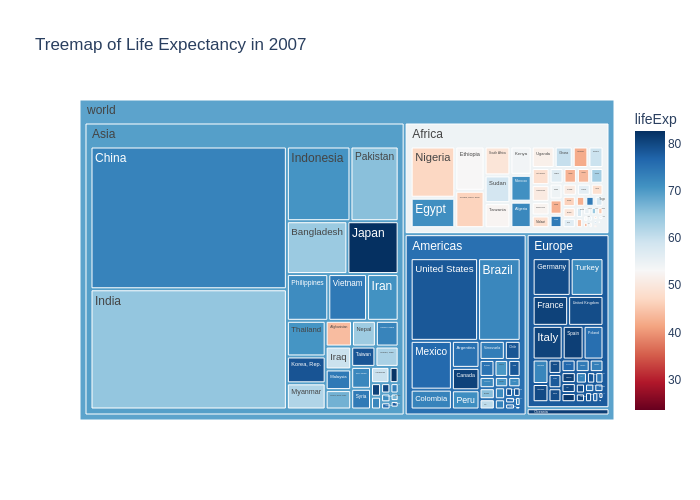

In [5]:
# a) Plot and compare two Treemap charts with a life expectancy color map, and population rectangle size: One in 1952 and one in 2007. 
# To consider: what color range for comparison? How to set the hierarchy?
# year 2007
min_lifeexp = df['lifeExp'].min()
max_lifeexp = df['lifeExp'].max()
year = 2007
fig = px.treemap(df[df['year']==year], 
                  path=[px.Constant("world"), 'continent', 'country'], 
                  values='pop',
                  color='lifeExp',
                  color_continuous_scale='RdBu',
                  range_color=[min_lifeexp,max_lifeexp],
                  title=f'Treemap of Life Expectancy in {year}'
                  )
fig.show(renderer="png") # we don't plot it interactive for now (requires kaleido for non-interactive)



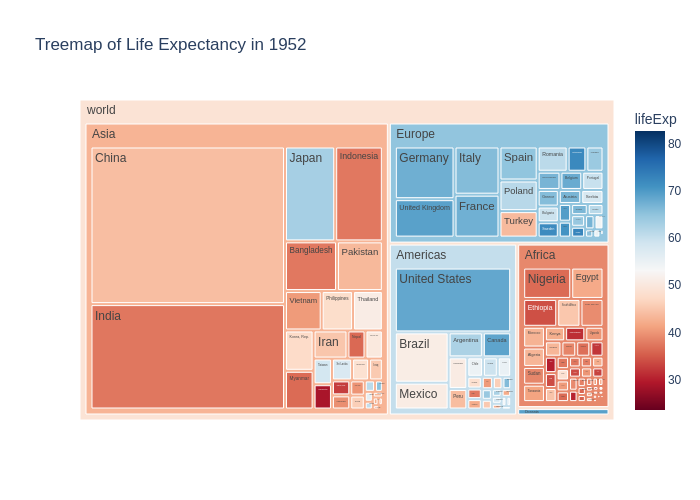

In [9]:
# a) year 1952
year = 1952
fig = px.treemap(df[df['year']==year], path=[px.Constant("world"), 'continent', 'country'], values='pop',
                  color='lifeExp', 
                  hover_data=['iso_alpha'],
                  color_continuous_scale='RdBu',
                  range_color=[min_lifeexp,max_lifeexp],
                  title=f'Treemap of Life Expectancy in {year}')
fig.show(renderer="png") # we don't plot it interactive for now (requires kaleido for non-interactive)


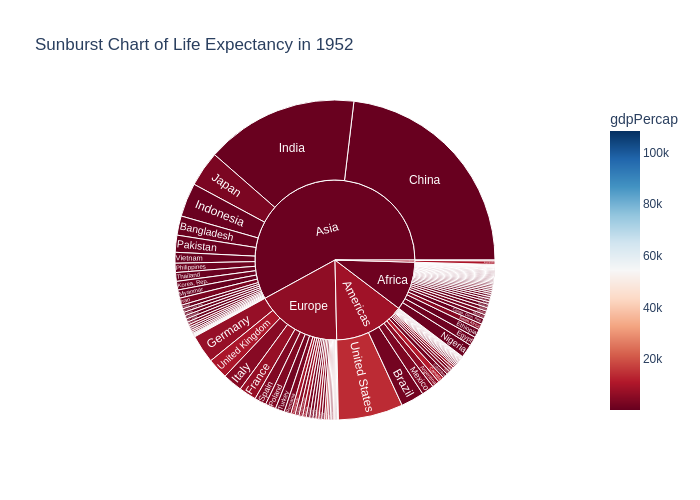

In [10]:
# b) Plot the Sunburst Chart of gdpPercap in 1952. Why is it difficult to see differences with default color range or range_color=[min_gdp,max_gdp]? 
# What solution can be found? 
year = 1952
min_gdp = df[df['year']==year]['gdpPercap'].min()
max_gdp = df[df['year']==year]['gdpPercap'].max()
fig = px.sunburst(df[df['year']==year], path=['continent', 'country'], values='pop',
                  color='gdpPercap',
                  color_continuous_scale='RdBu',
                  range_color=[min_gdp,max_gdp],
                  title=f'Sunburst Chart of Life Expectancy in {year}'
                  )
fig.show(renderer="png")



In [11]:
# b) 
df.nlargest(10,['gdpPercap'])
# Kuwait seems an outlier and makes the color range too spread (up to 113k). Other values between 0 and 10k seem to have the same color. 
# Solution: Set a smaller maximum value for the color-range (e.g. 30k, 40k). 
# Set another color scale with more color variation like rainbow
# or, 
# Make sure to clarify it when presenting the visualization because it modifies the real dataset.

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
853,Kuwait,Asia,1957,58.033,212846,113523.13290,KWT,414
856,Kuwait,Asia,1972,67.712,841934,109347.86700,KWT,414
852,Kuwait,Asia,1952,55.565,160000,108382.35290,KWT,414
854,Kuwait,Asia,1962,60.470,358266,95458.11176,KWT,414
855,Kuwait,Asia,1967,64.624,575003,80894.88326,KWT,414
857,Kuwait,Asia,1977,69.343,1140357,59265.47714,KWT,414
1151,Norway,Europe,2007,80.196,4627926,49357.19017,NOR,578
863,Kuwait,Asia,2007,77.588,2505559,47306.98978,KWT,414
1367,Singapore,Asia,2007,79.972,4553009,47143.17964,SGP,702
1150,Norway,Europe,2002,79.050,4535591,44683.97525,NOR,578


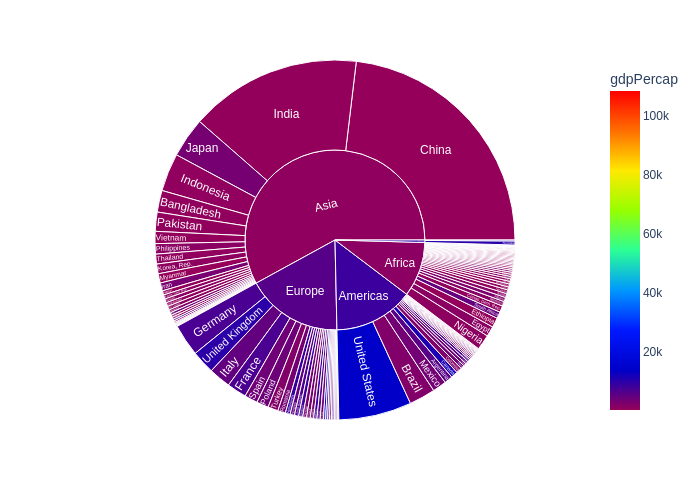

In [12]:
# b) Set another color scale
year = 1952
min_gdp = df[df['year']==year]['gdpPercap'].min()
max_gdp = df[df['year']==year]['gdpPercap'].max()
fig = px.sunburst(df[df['year']==year], path=['continent', 'country'], values='pop',
                  color='gdpPercap',
                  color_continuous_scale='rainbow',
                  range_color=[min_gdp,max_gdp],
                  )
fig.show(renderer="png")



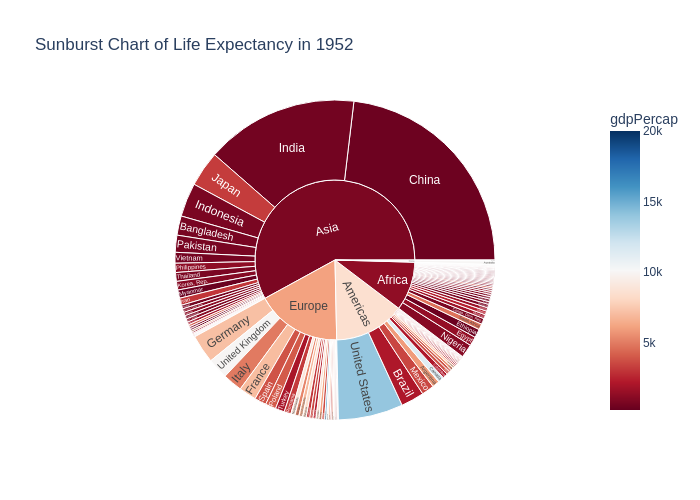

In [13]:
# b) Set a smaller maximum value
min_gdp = df['gdpPercap'].min()
max_gdp = 20000
fig = px.sunburst(df[df['year']==year], path=['continent', 'country'], values='pop',
                  color='gdpPercap',
                  color_continuous_scale='RdBu',
                  range_color=[min_gdp,max_gdp],
                  title=f'Sunburst Chart of Life Expectancy in {year}'
                  )
fig.show(renderer="png")
